In [3]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('C:/jupyter/VideoGamesProject-main/VideoGamesSales.csv')
df=df[df.duplicated()]
df.shape[0]

16

In [3]:
df=pd.read_csv('C:/jupyter/VideoGamesProject-main/VideoGamesSales.csv')
df=df.drop_duplicates()
df=df.info()
#df.shape[0]

<class 'pandas.DataFrame'>
Index: 5893 entries, 0 to 5908
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           5893 non-null   int64  
 1   Name           5893 non-null   str    
 2   Platform       5893 non-null   str    
 3   Year           5893 non-null   int64  
 4   Month          5893 non-null   str    
 5   Genre          5893 non-null   str    
 6   Publisher      5881 non-null   str    
 7   Country        5893 non-null   str    
 8   City           5893 non-null   str    
 9   State          5893 non-null   str    
 10  Region         5866 non-null   str    
 11  NA_Sales       5893 non-null   str    
 12  Global_Sales   5893 non-null   float64
 13  NA_Profit      5893 non-null   float64
 14  Global_Profit  5893 non-null   float64
dtypes: float64(3), int64(2), str(10)
memory usage: 736.6 KB


In [4]:
df=pd.read_csv('C:/jupyter/VideoGamesProject-main/VideoGamesSales.csv')
df=df.drop_duplicates()

df['Region']=df['Region'].fillna('North')
#df=df[df['Region'].isnull()]
#df=df.info()
#df.shape[0]

df['Publisher']=df['Publisher'].fillna('Ninetendo')
#df=df[df['Publisher'].isnull()] 
df.shape[0]

df['NA_Sales']=df['NA_Sales'].replace('[$]','',regex=True)
df.head(100)

df['Country'] =df['Country'].replace({'USA':'United States'})
df['Country'] =df['Country'].str.title()

#df=df[df['Country']=='Australia']
#df.shape[0]
df=df.rename(columns={'NA_Sales':'National Sales','Global_Sales':'Global Sales','NA_Profit':'National Profit','Global_Profit':'Global Profit'})

df['National Sales'] = pd.to_numeric(df['National Sales'])

sales_cap = df['National Sales'].quantile(0.95)
df['National Sales'] = np.where (df['National Sales'] > sales_cap,sales_cap, df['National Sales'])
df.head(5)

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National Profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,2.07,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,2.07,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,2.07,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,2.07,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,2.07,31.37,3.381,9.411


In [11]:
pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.3 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 2.3 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.3 MB 2.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 2.5 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 2.6 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.3 MB 2.7 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 2.9 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 3.0 MB/s eta 0:00:02
   ---------------------------- ----------- 6.0/8.3 MB 3.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 3.2 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 3.2 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


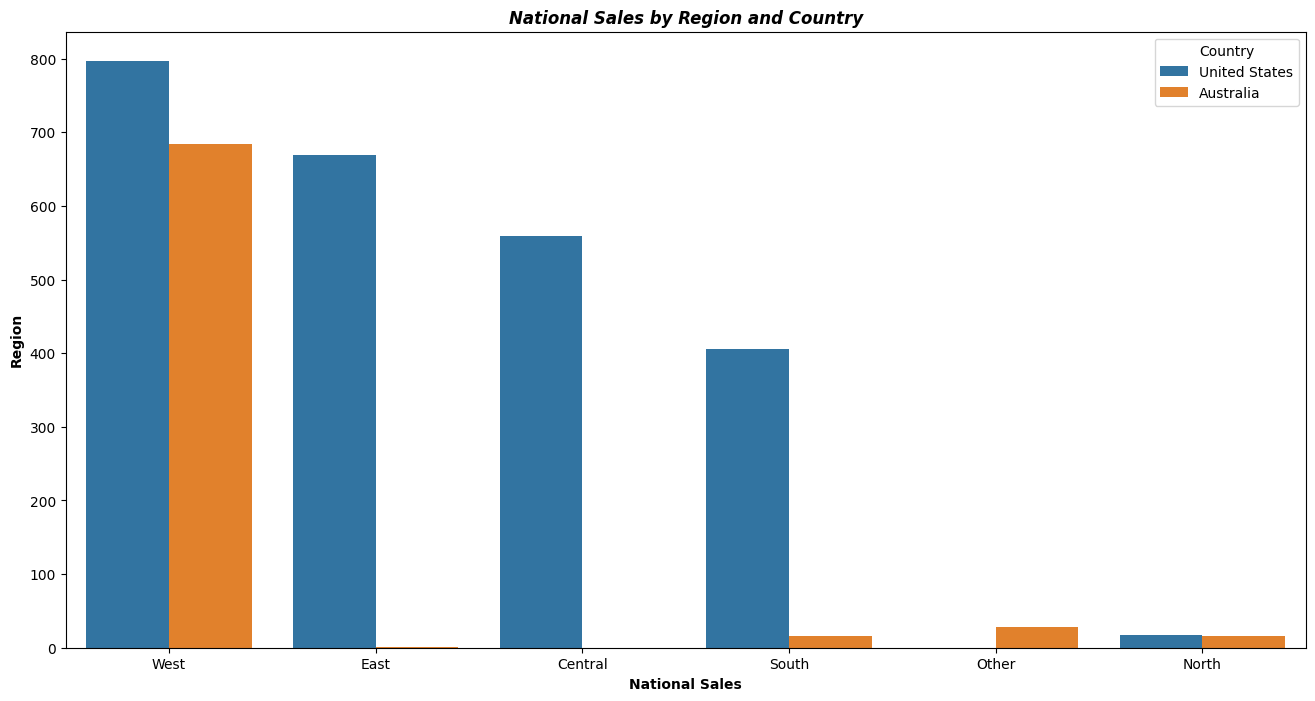

In [5]:
#Bar chart
National_Sales = df.groupby(['Region','Country'])['National Sales'].sum().reset_index().sort_values(by='National Sales',ascending=False)
National_Sales

plt.figure(figsize = (16,8))

sns.barplot(data = National_Sales , x = 'Region', y = 'National Sales', hue = 'Country')

plt.title('National Sales by Region and Country',fontweight= 'bold', fontstyle='italic')
plt.xlabel('National Sales',fontweight= 'bold')
plt.ylabel('Region',fontweight= 'bold')
plt.show()

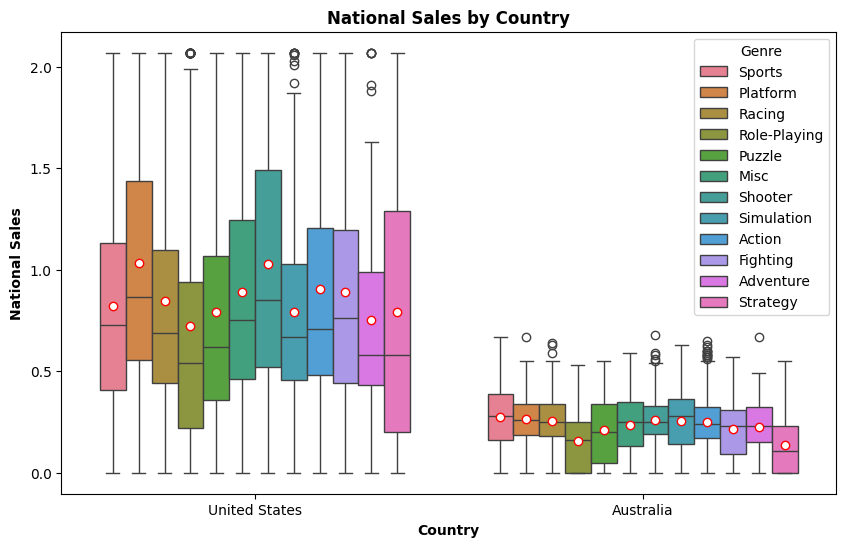

In [6]:
#Box plot
plt.figure(figsize=(10,6))

sns.boxplot(data= df, x= 'Country', y= 'National Sales',showmeans= True, hue= 'Genre',meanprops= {  "marker":"o"
                                                                                                    ,"markerfacecolor":"white"
                                                                                                    ,"markersize":"6"
                                                                                                    ,"markeredgecolor":"red" } )
    

plt.title('National Sales by Country',fontweight= 'bold')
plt.xlabel('Country',fontweight= 'bold')
plt.ylabel('National Sales',fontweight= 'bold')
plt.show()

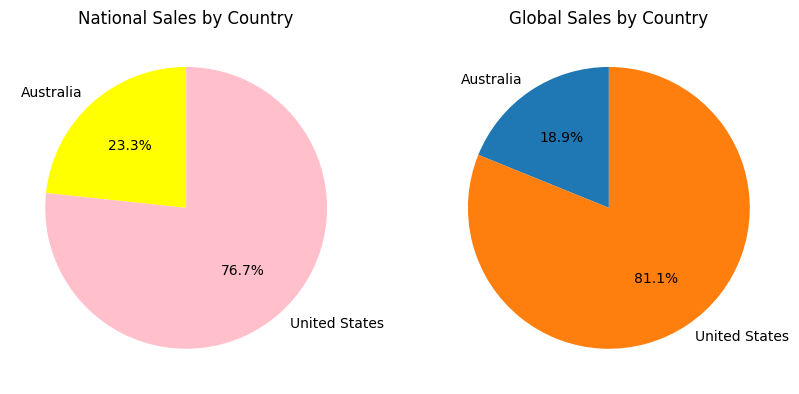

In [28]:
#Pie chart
Sales = df.groupby(['Country'])[['National Sales', 'Global Sales']].sum().reset_index()

Country= Sales ['Country']
National_Sales= Sales ['National Sales']
Global_Sales= Sales ['Global Sales']

colors1= ['yellow','pink']
fig,axs = plt.subplots(1,2, figsize= (10,7))

axs[0].pie (National_Sales, labels= Country, autopct= '%1.1f%%', startangle= 90, colors=colors1)
axs[0].set_title ('National Sales by Country')

axs[1].pie (Global_Sales, labels= Country, autopct= '%1.1f%%', startangle= 90)
axs[1].set_title ('Global Sales by Country')
plt.show()

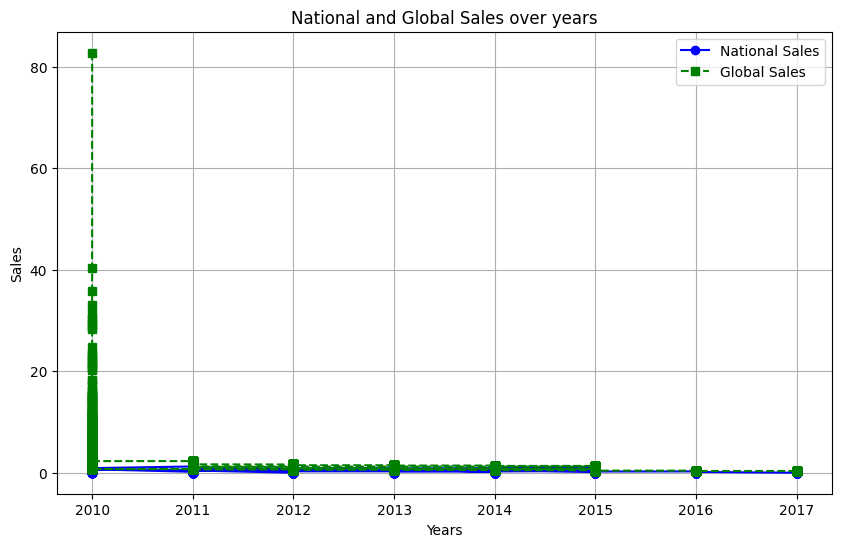

In [31]:
#Line chart
plt.figure(figsize= (10,6))

plt.plot(df['Year'],df['National Sales'],marker= 'o', linestyle= '-', color= 'b', label= 'National Sales')
plt.plot(df['Year'],df['Global Sales'],marker= 's', linestyle= '--', color= 'g', label= 'Global Sales')

plt.title('National and Global Sales over years')
plt.xlabel('Years')
plt.ylabel('Sales')
plt.legend()

plt.grid(True)
plt.show()